In [1]:
#The purpose of this code is to extract energy demand data, and meteorlogical data from reanalysis data. 
# Once that is completed, the next step is to transform the data. 
# Primarily to common times and remove missing data
# Finally once that is complete numerous ML models can be trained and evaluated

### Ethan Collins 2025 ###


In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import netCDF4
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import holidays
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


## Functions

In [3]:
def preprocess_dataset_era5(path_pattern):
    
    '''This function opens all of the era5 data in a folder
    Then it will only select data within CONUS
    Then it will look through all variables and if any temperature values are in Kelvin they will be converted to C
    and finally if there are U and V compontents of the wind at 10m, wind speed will be calculated and saved'''
    ds1 = xr.open_mfdataset(
        path_pattern,
        engine="netcdf4",
        combine="by_coords"
    )

    ds_conus = ds1.sel(
        latitude=slice(50,24), 
        longitude=slice(-125, -66)
    )

    da_vars = {}

    for name, da in ds_conus.data_vars.items():
        long_name = da.attrs.get("long_name", "").lower()
        units = da.attrs.get("units", "").upper()

        # Convert temperatures from K -> C
        if "temperature" in long_name and units == "K":
            da = da - 273.15
            da.attrs["units"] = "C"
            da.attrs["long_name"] = da.attrs.get("long_name", name)
        da_vars[name] = da


    if "u10" in da_vars and "v10" in da_vars:
        da_vars["wind"] = np.sqrt(da_vars["u10"]**2 + da_vars["v10"]**2)
        da_vars["wind"].attrs.update({"units": "m/s", "long_name": "10m wind speed"})
        
    vas=xr.Dataset(da_vars)
    mean_spatial = vas.mean(dim=['latitude', 'longitude'])
    time_1=time_dim_name(mean_spatial)
    mean_spatial = mean_spatial.dropna(dim=time_1, how="any")
    return xr.Dataset(mean_spatial)

In [4]:
def preprocess_dataset_energy(path_pattern):
    '''This function opens the energy data within a folder
        Then it will find the mean per hour of the type of data. Since there are numerous sources, this allows
        For there to be one value per hour for energy demand, type, etc.
        Once that is completed, this function will select the energy demand variable and return the hourly means'''
    df = pd.read_csv(path_pattern)
    ds = df.to_xarray()

    ds_collapsed = ds.groupby(["period", "type"]).mean(dim="index", skipna=True)

    ds_collapsed = ds_collapsed.assign_coords(
        period=pd.to_datetime(ds_collapsed['period'].values)
    )
    da_D = ds_collapsed.sel(type='D')['value']
    time_1=time_dim_name(da_D)
    da_D = da_D.dropna(dim=time_1, how="any")
    return da_D

In [5]:
def time_dim_name(data_1):
    '''This function computes what the time dimension name is'''
    for coord in data_1.coords:
        values = data_1[coord].values
        if np.issubdtype(values.dtype, np.datetime64):
            return coord
    raise ValueError("No datetime coordinate found in Dataset.")


In [6]:
def transform_data(data_1,data_2):
    '''This function transforms all data into a useable formate
    It will remove any NaN data
    It will then find all common times between two data sets and remove any times that are only in one 
    It will compute time features, such as hour, dayofweek, month, weekend,holiday'''
    time_1=time_dim_name(data_1)
    time_2=time_dim_name(data_2)

    data_first_clean = data_1.dropna(dim=time_1, how="any")
    data_second_clean = data_2.dropna(dim=time_2, how="any")


    times_in_common = pd.Index(data_1[time_1].values).intersection(
        pd.Index(data_2[time_2].values)
    ).values    
    ds1_common = data_first_clean.sel(**{time_1: times_in_common})
    ds2_common = data_second_clean.sel(**{time_2: times_in_common})
    
    print("step1")
    # Add time data to one of the data set (Primarily want if weekend, if holiday, month, etc.)
    us_holidays = holidays.US()

    # Create DatetimeIndex
    ti = pd.DatetimeIndex(ds2_common[time_2].values)


    time_features = xr.Dataset({
        "hour": (time_2, ti.hour),
        "dayofweek": (time_2, ti.weekday),
        "month": (time_2, ti.month),
        "weekend": (time_2, ti.weekday >= 5),
        "holiday": (time_2, [d in us_holidays for d in ti.date])
    }, coords={time_2: ds2_common[time_2]})


    return ds1_common,ds2_common, time_features


In [7]:
def add_lag_mean(ds, roll_windows, lag_steps):
    """
    Add rolling, lag, and differencing features for all numeric variables
    in an xarray Dataset along the time dimension.
    """
    
    # Detect time dimension name
    time_dim = time_dim_name(ds)

    max_window = max(
        (max(roll_windows) if roll_windows else 0),
        (max(lag_steps) if lag_steps else 0)
    )
        
    # Loop through all data variables
    for var in ds.data_vars:
        
        # Only process numeric variables
        if not np.issubdtype(ds[var].dtype, np.number):
            continue

        for w in roll_windows:
            ds[f"{var}_roll{w}_mean"] = ds[var].rolling({time_dim: w}, min_periods=1).mean()
            ds[f"{var}_roll{w}_std"]  = ds[var].rolling({time_dim: w}, min_periods=1).std()

        for l in lag_steps:
            ds[f"{var}_lag{l}"] = ds[var].shift({time_dim: l})

        ds[f"{var}_diff1"] = ds[var].diff(time_dim)
        ds[f"{var}_diff2"] = ds[f"{var}_diff1"].diff(time_dim)
    print("removing")
    ds = ds.isel({time_dim: slice(max_window, None)})

    return ds


In [8]:
def test_train_data (data_1,data_2,data_3,test_num):
    '''This function will split the data into training and testing data that will be used for the machine learning model'''
    data_var_names_1 = list(data_1.data_vars)
    data_var_names_3 = list(data_3.data_vars)    
    x_series=[]
    name_var=[]
    for name in data_var_names_1:
        x_series.append(data_1[name].to_series())
        name_var.append(name)
        
    for name in data_var_names_3:
        x_series.append(data_3[name].to_series())
        name_var.append(name)
    
    X = pd.concat(x_series, axis=1)

    X.columns = name_var
    y_series = data_2.to_series()    
    y = y_series
    
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_num, random_state=0
)
    return X_train, X_test, y_train, y_test

In [9]:
def ml_model(which_model,X_train, X_test, y_train, y_test,feature_select=False,
    importance_thresh=0.01,
    coef_thresh=1e-4, **kwargs):
    '''This function allows the user to select one of three modelss andd the training and testing data'''
    if which_model == "linear_regression":

        name_model="Linear Regression"
        model = LinearRegression()

    if which_model == "random_forest":
        name_model="Random Forest"

        model = RandomForestRegressor(
        n_estimators=kwargs.get("n_estimators", 100),   # number of trees
        random_state=kwargs.get("random_state", 42),
        max_depth=kwargs.get("max_depth", None),     # you can limit tree depth
        n_jobs=kwargs.get("n_jobs", -1)          # use all CPU cores
    )


    if which_model=="xgboost":
        name_model="XGBoost"
        
        # Step 1: Create the model
        model = xgb.XGBRegressor(
            n_estimators=kwargs.get("n_estimators",500),      # number of trees
            learning_rate=kwargs.get("learning_rate",0.05),    # step size shrinkage
            max_depth=kwargs.get("max_depth", 5),           # maximum depth of each tree
            subsample=kwargs.get("subsample", 0.8),         # fraction of samples used per tree
            colsample_bytree=kwargs.get("colsample_bytree", 0.8),  # fraction of features used per tree
            random_state=kwargs.get("random_state", 42)
        )


    model.fit(X_train, y_train)
    selected_features = X_train.columns
    
    if feature_select:

        # ---- Linear Regression ----
        if which_model == "linear_regression":
            coefs = pd.Series(
                np.abs(model.coef_),
                index=X_train.columns
            ).sort_values(ascending=False)

            selected_features = coefs[coefs >= coef_thresh].index

        # ---- Tree-based models ----
        elif hasattr(model, "feature_importances_"):
            importances = pd.Series(
                model.feature_importances_,
                index=X_train.columns
            ).sort_values(ascending=False)

            selected_features = importances[importances >= importance_thresh].index

        # ---- Refit with selected features ----
        X_train = X_train[selected_features]
        X_test  = X_test[selected_features]

        model.fit(X_train, y_train)

    # --------------------
    # Predict
    # --------------------
    y_pred = model.predict(X_test)

    return y_pred, selected_features
        


In [10]:
def model_eval(model_preds,number_of_events):
    '''This function evaluates the energy ML models that were trained
    Need to provide model output, and number of extreme events you want to evaluate'''
    results = {}
    for name, preds in model_preds.items():

        results[name] = {
            "MSE": mean_squared_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "MAE": mean_absolute_error(y_test, preds),
            "R²": r2_score(y_test, preds),
            "Normalized MSE": mean_squared_error(y_test, preds) / np.var(y_test)
        }

    df_results = pd.DataFrame(results).T
    print(df_results)

    for name, preds in model_preds.items():

        plt.figure(figsize=(6,5))    
        plt.scatter(y_test, preds, alpha=0.5,color='blue')
        plt.plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 'r--', lw=2)
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.title(f"{name}: Predicted vs Actual")
        plt.grid(True)
        plt.show()

    plt.figure(figsize=(10, 8))
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'k--')

    for name, preds in model_preds.items():
        plt.scatter(y_test, preds, alpha=0.35, label=name)

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.legend()
    plt.title("Actual vs Predicted")
    plt.show()

    plt.figure(figsize=(10,6))
    for name, preds in model_preds.items():
        errors = y_test - preds
        plt.hist(errors, bins=40, alpha=0.5, label=name)

    plt.title("Error Distribution Comparison")
    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    TOP_N = number_of_events
    plt.figure(figsize=(10,6))
    # Find the timestamps of the actual top N peaks
    actual_peaks = y_test.nlargest(TOP_N)
    peak_times = actual_peaks.index

    plt.figure(figsize=(10,6))

    # Plot actual peak values
    plt.plot(actual_peaks.values, label="Actual Peaks", marker='o')

    # For each model, get predictions *at those same timestamps*
    for name, preds in model_preds.items():

        preds_series = pd.Series(preds, index=y_test.index)
        matched_pred_peaks = preds_series.loc[peak_times]

        plt.plot(matched_pred_peaks.values, label=f"{name} Predicted Peaks", marker='x')

    plt.title(f"Top {TOP_N} Energy Demand Peaks — Model Accuracy at Actual Peak Times")
    plt.xlabel("Peak Rank")
    plt.ylabel("Energy Demand")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(10,6))

    # Plot actual peak values
    #plt.plot(actual_peaks.values, label="Actual Peaks", marker='o')

    # For each model, get predictions *at those same timestamps*
    for name, preds in model_preds.items():

        preds_series = pd.Series(preds, index=y_test.index)
        matched_pred_peaks = preds_series.loc[peak_times]

        plt.plot((actual_peaks.values-matched_pred_peaks.values), label=f"{name} Predicted Peaks", marker='x')

    plt.title(f"Error of top {TOP_N} Energy Demand Peaks — Model Accuracy at Actual Peak Times")
    plt.xlabel("Peak Rank")
    plt.ylabel("Actual Energy Demand - Predicted Energy Demand")
    plt.legend()
    plt.grid(True)
    plt.show()



## Extract Meteorology data, and Energy data

In [11]:
%%time
meteorology_data=preprocess_dataset_era5("eta_2025_*.nc")
energy_data=preprocess_dataset_energy("eia_load_data.csv")

CPU times: user 1min 10s, sys: 11.5 s, total: 1min 21s
Wall time: 1min 16s


## Transform Data into usable arrays. We want common times, NaNs dropped, etc.

In [12]:
%%time
meteorology=add_lag_mean(meteorology_data,[3, 6, 12, 24],[1, 2, 3, 6, 12, 24])


removing
CPU times: user 3.23 s, sys: 66.8 ms, total: 3.3 s
Wall time: 3.78 s


In [13]:
%%time
meteorology, energy, time= transform_data(meteorology,energy_data)

step1
CPU times: user 8min 26s, sys: 2min 37s, total: 11min 3s
Wall time: 9min 21s


## Generate the test and train data for the ML Models

In [14]:
X_train, X_test, y_train, y_test=test_train_data(meteorology, energy, time,0.2)

## Train different Models

In [15]:
# List of models to run
models_to_run = ["linear_regression", "xgboost", "random_forest"]

model_name_map = {
    "linear_regression": "Linear Regression",
    "xgboost": "XGBoost",
    "random_forest": "Random Forest"
}

model_output = {}

for model_key in models_to_run:
    if model_key == "xgboost":
        n_estimators=1000
    y_pred,features = ml_model(model_key, X_train, X_test, y_train, y_test,feature_select=False,
    coef_thresh=5e-4)
    model_output[model_name_map[model_key]] = y_pred

In [16]:
print(y_pred)

[27163.06208955 20315.97791045 17542.70776119 ... 19892.29835821
 24197.04059701 21998.90701493]


## Now that we have trained a model, we need to evaluate this model

                            MSE         RMSE          MAE        R²  \
Linear Regression  2.558270e+06  1599.459392  1260.549597  0.818360   
XGBoost            1.161886e+05   340.864536   265.027753  0.991751   
Random Forest      3.118574e+05   558.441921   417.467839  0.977858   

                   Normalized MSE  
Linear Regression        0.181640  
XGBoost                  0.008249  
Random Forest            0.022142  


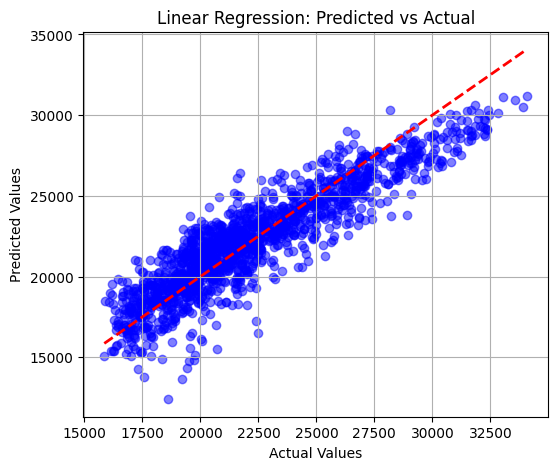

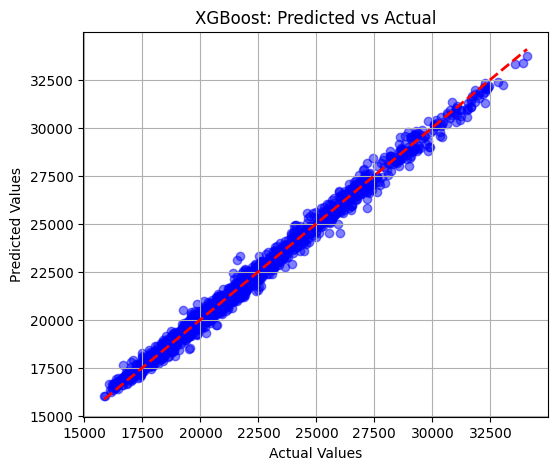

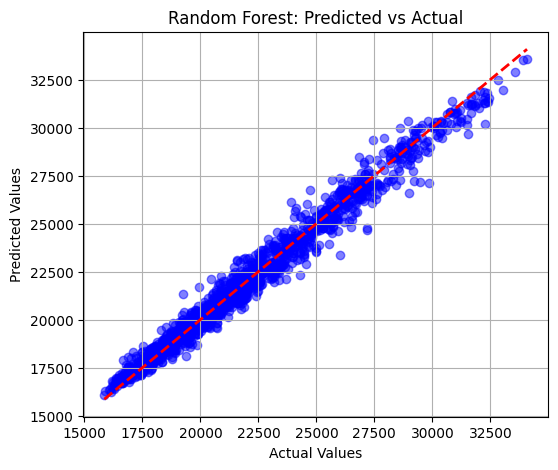

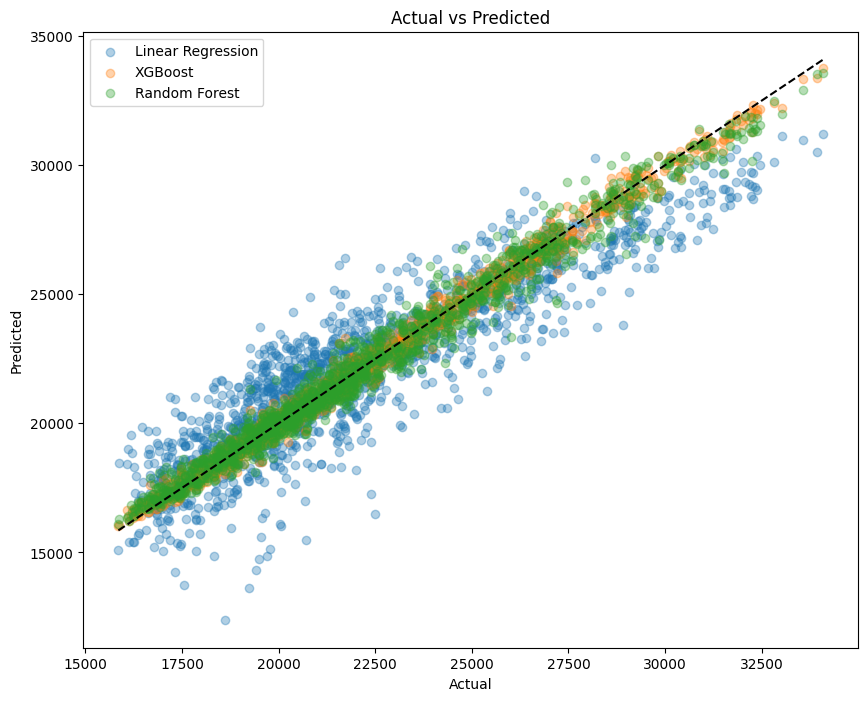

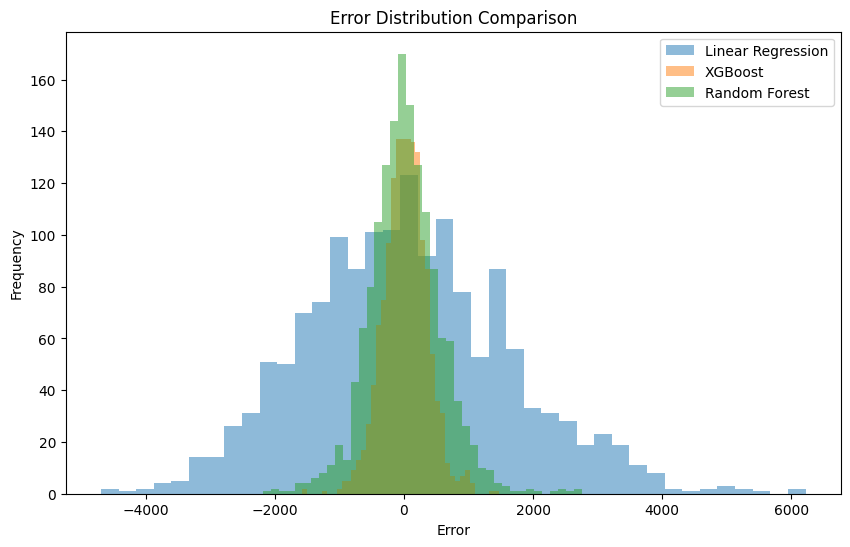

<Figure size 1000x600 with 0 Axes>

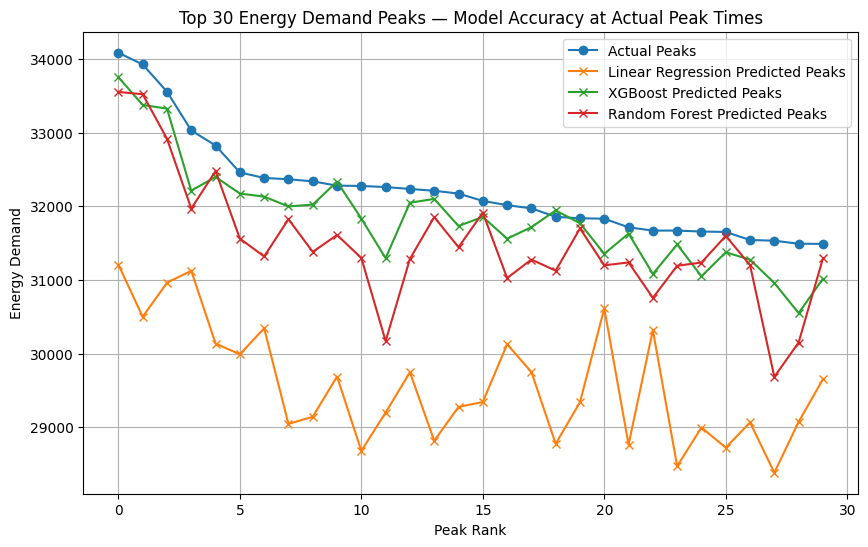

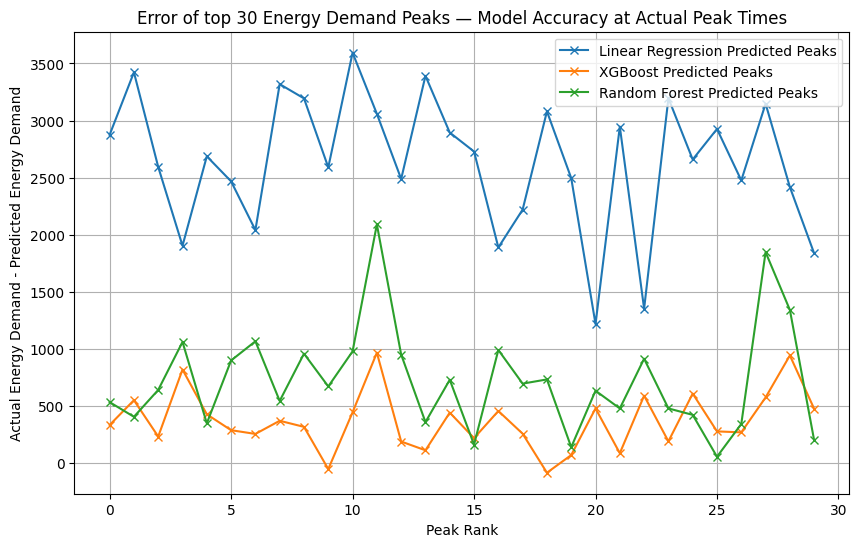

In [17]:
model_eval(model_output,30)

## Need to turn into funcitons and plots

In [18]:
def evaluate_peak_predictions(
    y_test,
    model_preds,
    TOP_N=10,
    HIT_WINDOW_HOURS=6
):
    """
    Evaluate how well models predict the TOP_N highest peaks in y_test.
    """

    # -------------------------------
    # 1. Extract actual top-N peaks
    # -------------------------------
    actual_peaks = y_test.nlargest(TOP_N)

    all_results = []
    timing_scatter = []  # for plotting
    summary_stats = []

    for model_name, preds in model_preds.items():

        # Ensure predictions align with y_test index
        pred_series = pd.Series(preds, index=y_test.index)
        pred_peaks = pred_series.nlargest(TOP_N)

        hit_count = 0
        model_records = []

        for t_actual, v_actual in actual_peaks.items():

            # Compute timing differences to each predicted peak
            time_diffs = pd.Series(
                np.abs((pred_peaks.index - t_actual) / np.timedelta64(1, 'h')),
                index=pred_peaks.index
            )

            # Closest predicted peak
            closest_time = time_diffs.idxmin()
            closest_pred_value = pred_series.loc[closest_time]
            time_error = time_diffs.loc[closest_time]
            magnitude_error = closest_pred_value - v_actual

            # Peak hit counting
            if time_error <= HIT_WINDOW_HOURS:
                hit_count += 1

            # Store results
            record = {
                "Model": model_name,
                "Actual Peak Time": t_actual,
                "Actual Peak Value": v_actual,
                "Pred Peak Time": closest_time,
                "Pred Peak Value": closest_pred_value,
                "Time Error (hours)": time_error,
                "Magnitude Error": magnitude_error
            }
            all_results.append(record)
            model_records.append(record)

            # For scatter plot
            timing_scatter.append({
                "Model": model_name,
                "Actual Time": t_actual,
                "Predicted Time": closest_time,
                "Time Error": time_error
            })

        # -----------------------------
        # Summary metrics for each model
        # -----------------------------
        model_df = pd.DataFrame(model_records)

        summary_stats.append({
            "Model": model_name,
            "Hit Rate (%)": 100 * hit_count / TOP_N,
            "Mean Time Error (hrs)": model_df["Time Error (hours)"].mean(),
            "Median Time Error (hrs)": model_df["Time Error (hours)"].median(),
            "Mean Magnitude Error": model_df["Magnitude Error"].mean(),
            "RMSE Magnitude Error": np.sqrt((model_df["Magnitude Error"]**2).mean()),
        })

    results_df = pd.DataFrame(all_results)
    summary_df = pd.DataFrame(summary_stats)
    scatter_df = pd.DataFrame(timing_scatter)

    # -----------------------------
    # 2. Plot peak timing comparison
    # -----------------------------
    plt.figure(figsize=(10,6))
    for model_name in scatter_df["Model"].unique():
        df_m = scatter_df[scatter_df["Model"] == model_name]
        plt.scatter(
            df_m["Actual Time"], df_m["Predicted Time"],
            label=model_name, alpha=0.7
        )

    plt.plot(scatter_df["Actual Time"], scatter_df["Actual Time"],
             linestyle="--", color="black", label="Perfect Prediction")

    plt.title("Actual vs Predicted Peak Timing")
    plt.xlabel("Actual Peak Time")
    plt.ylabel("Predicted Peak Time")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # 3. Plot timing error distribution
    # -----------------------------
    plt.figure(figsize=(10,6))
    for model_name in results_df["Model"].unique():
        errors = results_df[results_df["Model"] == model_name]["Time Error (hours)"]
        plt.hist(errors, bins=20, alpha=0.5, label=model_name)

    plt.title("Timing Error Distribution (hours)")
    plt.xlabel("Time Error (hours)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # 4. Plot magnitude error distribution
    # -----------------------------
    plt.figure(figsize=(10,6))
    for model_name in results_df["Model"].unique():
        errors = results_df[results_df["Model"] == model_name]["Magnitude Error"]
        plt.hist(errors, bins=20, alpha=0.5, label=model_name)

    plt.title("Magnitude Error Distribution")
    plt.xlabel("Pred - Actual")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.show()

    return results_df, summary_df


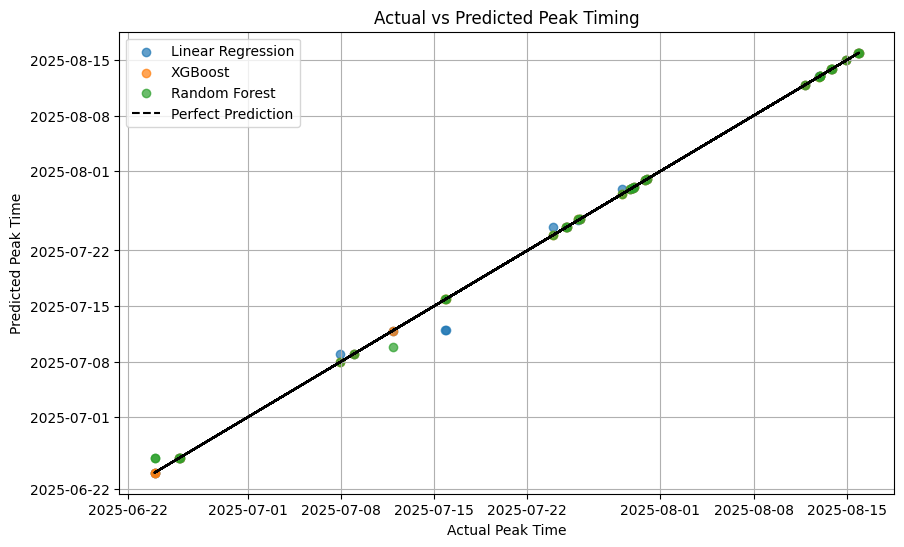

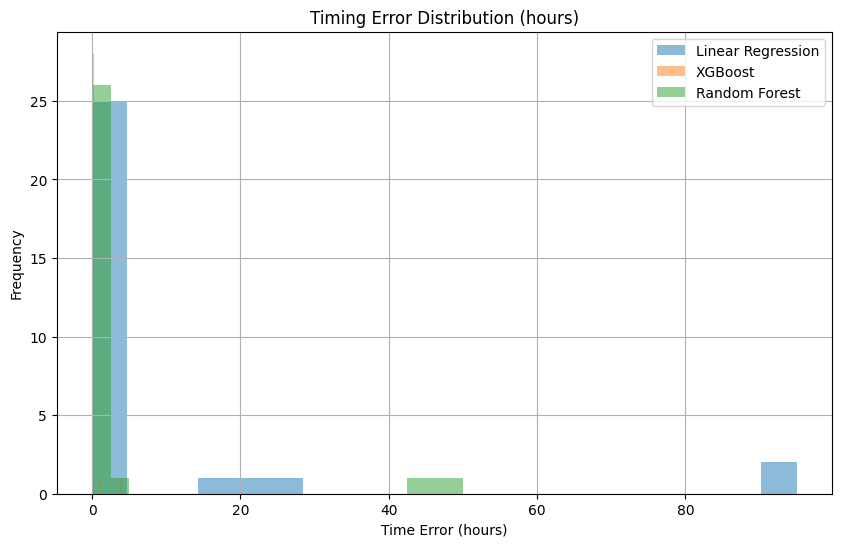

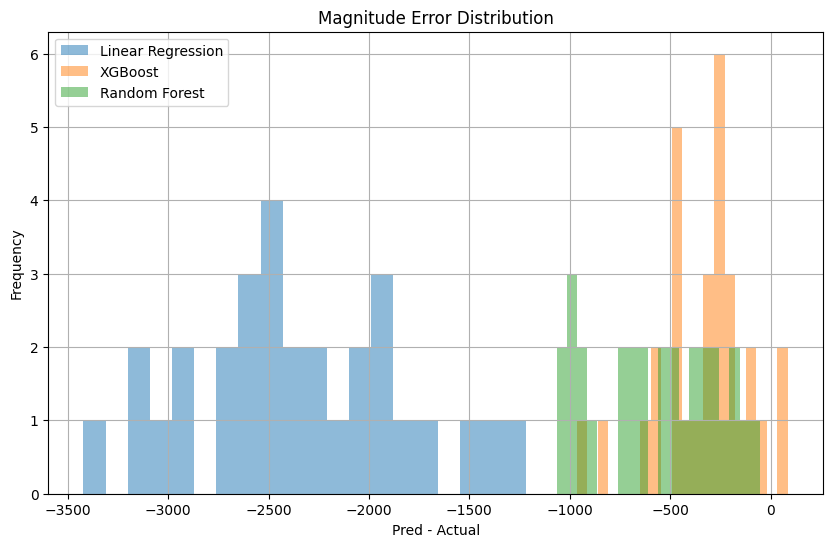

In [19]:
results_df, summary_df = evaluate_peak_predictions(
    y_test,
    model_output,
    TOP_N=30,
    HIT_WINDOW_HOURS=6
)
